# Q3 Bike Restocking

In [1]:
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from datetime import datetime as dt
import os
import seaborn as sns

In [20]:
# Loading data
essential_cols = ['month', 'started_at', 'ended_at', 'rideable_type', 'ride_id', 'start_station_name', 'end_station_name']

df = pd.read_pickle(r'../02_Data/df_merged_3.0.pkl')[essential_cols]

In [7]:
# ================================================================
# DYNAMIC RESTOCKING MODEL — with Month and Hour
# ================================================================
# Objective: Identify WHEN and WHERE stations need restocking
# ================================================================

# ------------------------------------------------
# 0. Prepare time columns
# ------------------------------------------------
# Ensure your dataset has a 'started_at' and 'ended_at' datetime column
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

# Extract month and hour
df['month'] = df['started_at'].dt.month
df['hour'] = df['started_at'].dt.hour

# ------------------------------------------------
# 1. Calculate total rides started and ended per station, month, and hour
# ------------------------------------------------
station_starts = (
    df.groupby(['start_station_name', 'month', 'hour'])['ride_id']
    .count()
    .reset_index(name='rides_started')
)

station_ends = (
    df.groupby(['end_station_name', 'month', 'hour'])['ride_id']
    .count()
    .reset_index(name='rides_ended')
)

# Merge start and end data
station_flow = pd.merge(
    station_starts,
    station_ends,
    left_on=['start_station_name', 'month', 'hour'],
    right_on=['end_station_name', 'month', 'hour'],
    how='outer'
)

# Clean column names
station_flow['station'] = station_flow['start_station_name'].combine_first(station_flow['end_station_name'])
station_flow = station_flow[['station', 'month', 'hour', 'rides_started', 'rides_ended']].fillna(0)

# ------------------------------------------------
# 2. Calculate net flow per station for each month and hour
# ------------------------------------------------
station_flow['net_flow'] = station_flow['rides_started'] - station_flow['rides_ended']

# Label station status
station_flow['status'] = station_flow['net_flow'].apply(
    lambda x: 'Needs Restocking' if x < -15 else ('Surplus Bikes' if x > 15 else 'Balanced')
)

# ------------------------------------------------
# 3. Identify high-demand stations (top 20% within each month)
# ------------------------------------------------
station_flow['total_activity'] = station_flow['rides_started'] + station_flow['rides_ended']

# Compute 80th percentile threshold *per month*
thresholds = (
    station_flow.groupby('month')['total_activity']
    .quantile(0.8)
    .reset_index()
    .rename(columns={'total_activity': 'threshold'})
)

# Merge thresholds back
station_flow = pd.merge(station_flow, thresholds, on='month', how='left')

# Filter popular stations per month
popular_stations = station_flow[station_flow['total_activity'] >= station_flow['threshold']]

# ------------------------------------------------
# 4. Display summary
# ------------------------------------------------
summary = (
    popular_stations.groupby(['month', 'status'])['station']
    .count()
    .reset_index(name='station_count')
)

print("Restocking Summary for Top 20% Stations (by Month):")
print(summary.head(12))


Restocking Summary for Top 20% Stations (by Month):
    month            status  station_count
0       1          Balanced           2863
1       1  Needs Restocking           2008
2       1     Surplus Bikes           1907
3       2          Balanced           2572
4       2  Needs Restocking           2290
5       2     Surplus Bikes           2018
6       3          Balanced           2048
7       3  Needs Restocking           2704
8       3     Surplus Bikes           2340
9       4          Balanced           2101
10      4  Needs Restocking           2729
11      4     Surplus Bikes           2388


In [8]:
popular_stations.head()

,station,month,hour,rides_started,rides_ended,net_flow,status,total_activity,threshold
6,1 Ave & E 110 St,1,7,83.0,28.0,55.0,Surplus Bikes,111.0,96.6
13,1 Ave & E 110 St,1,14,62.0,72.0,-10.0,Balanced,134.0,96.6
14,1 Ave & E 110 St,1,15,93.0,80.0,13.0,Balanced,173.0,96.6
15,1 Ave & E 110 St,1,16,71.0,80.0,-9.0,Balanced,151.0,96.6
16,1 Ave & E 110 St,1,17,62.0,96.0,-34.0,Needs Restocking,158.0,96.6


In [10]:
# ================================================================
# DYNAMIC RESTOCKING MODEL — Interactive Version (Month + Hour)
# ================================================================
# Objective: Visualize how bike availability fluctuates hourly by month
# ================================================================

import pandas as pd
import plotly.express as px

# ------------------------------------------------
# 0. Prepare time columns
# ------------------------------------------------
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])
df['month'] = df['started_at'].dt.month
df['hour'] = df['started_at'].dt.hour

# ------------------------------------------------
# 1. Calculate total rides started and ended per station, month, and hour
# ------------------------------------------------
station_starts = (
    df.groupby(['start_station_name', 'month', 'hour'])['ride_id']
    .count()
    .reset_index(name='rides_started')
)

station_ends = (
    df.groupby(['end_station_name', 'month', 'hour'])['ride_id']
    .count()
    .reset_index(name='rides_ended')
)

# Merge start and end data
station_flow = pd.merge(
    station_starts,
    station_ends,
    left_on=['start_station_name', 'month', 'hour'],
    right_on=['end_station_name', 'month', 'hour'],
    how='outer'
)

# Clean column names
station_flow['station'] = station_flow['start_station_name'].combine_first(station_flow['end_station_name'])
station_flow = station_flow[['station', 'month', 'hour', 'rides_started', 'rides_ended']].fillna(0)

# ------------------------------------------------
# 2. Calculate net flow per station (hourly, monthly)
# ------------------------------------------------
station_flow['net_flow'] = station_flow['rides_started'] - station_flow['rides_ended']
station_flow['total_activity'] = station_flow['rides_started'] + station_flow['rides_ended']

# ------------------------------------------------
# 3. Identify high-demand stations (top 20% each month)
# ------------------------------------------------
thresholds = (
    station_flow.groupby('month')['total_activity']
    .quantile(0.8)
    .reset_index()
    .rename(columns={'total_activity': 'threshold'})
)
station_flow = pd.merge(station_flow, thresholds, on='month', how='left')
popular_stations = station_flow[station_flow['total_activity'] >= station_flow['threshold']]

# ------------------------------------------------
# 4. Aggregate net flow by hour and month (across top stations)
# ------------------------------------------------
hourly_balance = (
    popular_stations.groupby(['month', 'hour'])['net_flow']
    .mean()
    .reset_index()
)

In [12]:
hourly_balance.head()

,month,hour,net_flow
0,1,0,-63.000000
1,1,5,44.111111
2,1,6,-19.425926
3,1,7,-6.052632
4,1,8,-4.191579


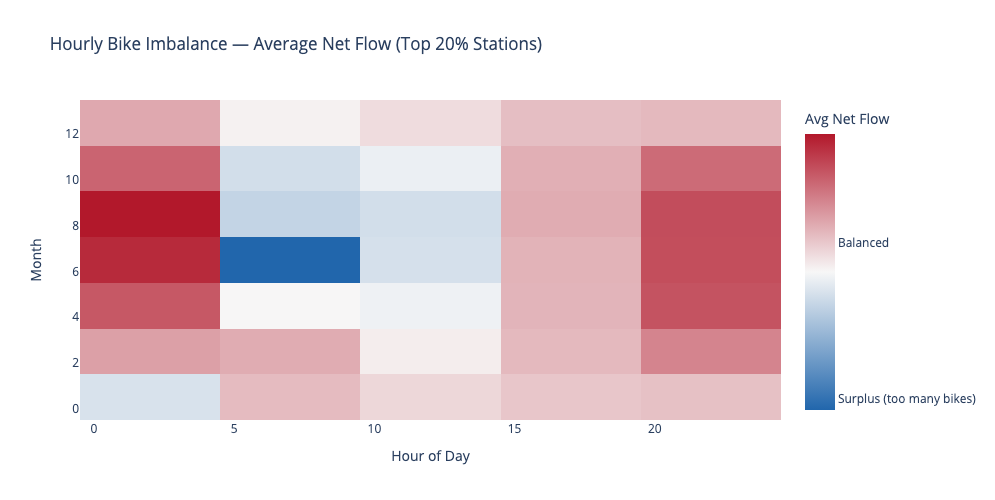

In [15]:
# ================================================================
# HOURLY RESTOCKING HEATMAP — Month vs Hour
# ================================================================
# Each cell = average net flow across top 20% busiest stations
# Red → bike deficit (stations losing bikes)
# Blue → bike surplus (stations filling up)
# ================================================================

import plotly.express as px

# Aggregate net flow across all top stations
heatmap_df = (
    popular_stations.groupby(['month', 'hour'])['net_flow']
    .mean()
    .reset_index()
)

fig = px.density_heatmap(
    heatmap_df,
    x='hour',
    y='month',
    z='net_flow',
    color_continuous_scale=['#2166ac', '#f7f7f7', '#b2182b'],
    title='Hourly Bike Imbalance — Average Net Flow (Top 20% Stations)',
    labels={
        'hour': 'Hour of Day',
        'month': 'Month',
        'net_flow': 'Avg Net Flow (Starts - Ends)'
    }
)

fig.update_layout(
    template='plotly_white',
    height=500,
    coloraxis_colorbar=dict(
        title='Avg Net Flow',
        tickvals=[-200, 0, 200],
        ticktext=['Surplus (too many bikes)', 'Balanced', 'Shortage (too few bikes)']
    )
)

fig.show()


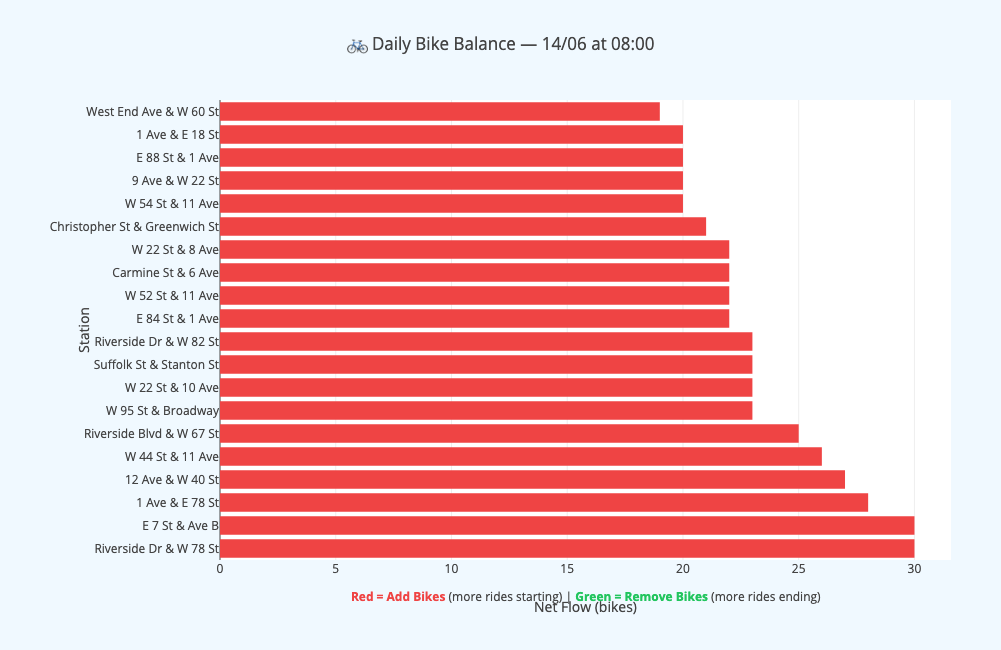

In [28]:
# ================================================================
# BIKE RESTOCKING MODEL — Daily-Level Version
# ================================================================
import pandas as pd
import plotly.graph_objects as go

# Prepare datetime parts
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])
df['month'] = df['started_at'].dt.month
df['day'] = df['started_at'].dt.day
df['hour'] = df['started_at'].dt.hour

# ------------------------------------------------
# 1. Calculate rides started / ended per station, per day
# ------------------------------------------------
station_starts = (
    df.groupby(['start_station_name', 'month', 'day', 'hour'])['ride_id']
    .count()
    .reset_index(name='rides_started')
)

station_ends = (
    df.groupby(['end_station_name', 'month', 'day', 'hour'])['ride_id']
    .count()
    .reset_index(name='rides_ended')
)

# Merge
station_flow = pd.merge(
    station_starts,
    station_ends,
    left_on=['start_station_name', 'month', 'day', 'hour'],
    right_on=['end_station_name', 'month', 'day', 'hour'],
    how='outer'
)

station_flow['station'] = station_flow['start_station_name'].combine_first(station_flow['end_station_name'])
station_flow = station_flow[['station', 'month', 'day', 'hour', 'rides_started', 'rides_ended']].fillna(0)

# ------------------------------------------------
# 2. Net flow per station, per day, per hour
# ------------------------------------------------
station_flow['net_flow'] = station_flow['rides_started'] - station_flow['rides_ended']
station_flow['total_activity'] = station_flow['rides_started'] + station_flow['rides_ended']

# ------------------------------------------------
# 3. Optional: Filter to top 20% busiest stations (for each month)
# ------------------------------------------------
thresholds = (
    station_flow.groupby('month')['total_activity']
    .quantile(0.8)
    .reset_index()
    .rename(columns={'total_activity': 'threshold'})
)
station_flow = pd.merge(station_flow, thresholds, on='month', how='left')
popular_stations = station_flow[station_flow['total_activity'] >= station_flow['threshold']]

# ------------------------------------------------
# 4. Example — show restocking needs for a specific day
# ------------------------------------------------
def create_daily_restocking_viz(month=6, day=14, hour=8):
    filtered = popular_stations[
        (popular_stations['month'] == month) &
        (popular_stations['day'] == day) &
        (popular_stations['hour'] == hour)
    ].copy()

    if filtered.empty:
        print(f"No data for {day:02d}.{month:02d} at {hour}:00")
        return None

    filtered = filtered.sort_values('net_flow', ascending=False).head(20)

    colors = ['#ef4444' if x > 0 else '#22c55e' for x in filtered['net_flow']]

    filtered['hover_text'] = filtered.apply(
        lambda r: f"<b>{r['station']}</b><br>"
                  f"Started: {int(r['rides_started'])} rides<br>"
                  f"Ended: {int(r['rides_ended'])} rides<br>"
                  f"<b>{'Add' if r['net_flow'] > 0 else 'Remove'}: {abs(int(r['net_flow']))} bikes</b>",
        axis=1
    )

    fig = go.Figure()
    fig.add_trace(go.Bar(
        y=filtered['station'],
        x=filtered['net_flow'],
        orientation='h',
        marker=dict(color=colors),
        hovertemplate='%{customdata}<extra></extra>',
        customdata=filtered['hover_text']
    ))

    fig.update_layout(
        title=f"🚲 Daily Bike Balance — {day:02d}/{month:02d} at {hour:02d}:00",
        xaxis_title='Net Flow (bikes)',
        yaxis_title='Station',
        height=650,
        plot_bgcolor='white',
        paper_bgcolor='#f0f9ff',
        margin=dict(l=220, r=50, t=100, b=90),
        annotations=[
            dict(
                text='<b style="color:#ef4444;">Red = Add Bikes</b> (more rides starting) | '
                     '<b style="color:#22c55e;">Green = Remove Bikes</b> (more rides ending)',
                xref='paper', yref='paper', x=0.5, y=-0.1,
                showarrow=False, font=dict(size=12), xanchor='center'
            )
        ]
    )

    fig.show()

# Example usage
create_daily_restocking_viz(month=6, day=14, hour=8)


In [46]:
popular_stations = popular_stations[popular_stations['station'] != 'nan']

In [47]:
popular_stations.to_parquet("popular_stations.parquet")